# Suggested signal model

Let the observable $h$ obey

$$ \ddot{h}+\gamma(t) \dot{h} + \omega^2(t)h = \xi(t).$$

Torsten suggested to use:

$$ \ddot{h}+\gamma(t) \dot{h} + \omega^2(t)h = 0$$

and use correalted fields for $\gamma(t)$ and $\mathrm{ln}(\omega(t))$ in order to solve the differential equation numerically in step. However, here we argue that if $\xi(t)$ is complicated enough, it should be able to represent any desired waveform for scalar $\omega$ and $\gamma$, permitting an analytical solution:

$$ \ddot{h}+\gamma \dot{h} + \omega^2 h = \xi(t).$$

To investigate this, we set $\gamma_{\mathrm{trial}}$ and $\omega^2_{\mathrm{trial}}$ to arbitrary constants and find the solution for $\xi(t)=0$, called $h_{\mathrm{trial}}$. We compare this waveform to a complicated GW waveform $h_{\mathrm{GW}}$ and find $\xi(t)_{\mathrm{correction}}$ such that the solution to

$$ \ddot{h}+\gamma_{\mathrm{trial}} \dot{h} + \omega^2_{\mathrm{trial}} h = \xi(t)_{\mathrm{correction}}$$

closely resembles $h_{\mathrm{GW}}$. We look at \xi(t) and judge whether it can be modelled via a correlated field model.

# Damped harmonic oscillator

The solution to the equation

$$\ddot{h}+\gamma_0 \dot{h} + \omega_0^2 h = 0 $$

with fixed $\gamma$ and $\omega^2$ is:

$$h_{\mathrm{trial}}=A\cdot (e^{\alpha \cdot \omega t}+e^{-\alpha\cdot  \omega t})$$

with $\alpha\in\mathbb{C}$ and iff $$\omega_{1,2}=\frac{i\gamma_0 \mp i \sqrt{4\omega_0^2-\gamma_0^2}}{2}$$. We omit $i$ in the exponent because $\omega$ is already complex in general.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib tk

In [ ]:
def get_frequencies(omega0, gamma0):
    discr = 1j * np.sqrt(4*omega0**2-gamma0**2+0j)
    omega_neg =  (1j * gamma0 - discr)/2
    omega_pos =  (1j * gamma0 + discr)/2
    return omega_neg, omega_pos

def get_h_trial(t, omega0, gamma0, A, alpha):
    omega_neg, omega_pos = get_frequencies(omega0=omega0, gamma0=gamma0)
    h_trial_pos = A * (np.exp(alpha * omega_pos * t) + np.exp(-alpha * omega_pos * t))
    h_trial_neg = A * (np.exp(alpha * omega_neg * t) + np.exp(-alpha * omega_neg * t))
    return h_trial_pos + h_trial_neg

In [ ]:
time = np.linspace(0, 20*np.pi, 10_00)

parameter_list = [1, 2, 3, 1]
omega0, gamma0, A, alpha = parameter_list

h_trial = get_h_trial(t=time, omega0=omega0, gamma0=gamma0, A=A, alpha=alpha)
plt.plot(time, h_trial.real)

# Damped harmonic oscillator, driven as to match numerical relativity waveform

The waveform is simply

$$\tilde{h}(\omega)=\frac{\tilde{\xi}(\omega)}{\omega^2-i\omega \gamma + \omega^2_0},$$

or,

$$\tilde{\xi}(\omega) = \tilde{h}(\omega)\cdot\big( \omega^2-i\omega \gamma + \omega^2_0\big).$$

In [ ]:
path1 = "/Users/iason/PycharmProjects/STRAIN/data/data_txt/num_rel_template_strain_values.txt"
path2 = "/Users/iason/PycharmProjects/STRAIN/data/data_txt/num_rel_template_time_values.txt"
gw_waveform = np.loadtxt(path1)*1e21
gw_times = np.loadtxt(path2)
gw_times = gw_times-gw_times[0]

In [ ]:
plt.plot(gw_times, gw_waveform)

In [ ]:
F = lambda p: np.fft.fft(p)
iF = lambda p: np.fft.ifft(p)
omega = np.fft.fftfreq(len(gw_times), d=gw_times[1]-gw_times[0])

In [ ]:
def get_xi(real_waveform, frequencies, gamma, omega0):
    omega = frequencies
    h_tilde = F(real_waveform)
    fac = omega**2 - 1j * omega * gamma + omega0**2
    real_xi_waveform = iF(h_tilde*fac)
    return real_xi_waveform/max(real_xi_waveform)

In [ ]:
real_xi = get_xi(real_waveform=gw_waveform, frequencies=omega, gamma=5000, omega0=3)

In [ ]:
plt.plot(gw_times, gw_waveform)
plt.plot(gw_times, real_xi.real)

# Numeric integration

$$\ddot{h}+\gamma(t) \dot{h} + \omega^2(t)h -  \xi(t) =0$$

Now define $u:=\dot{h}$, then this is equivalent to:

$$\dot{u}+\gamma(t) u + \omega^2(t) h -  \xi(t) =0,$$

defining

 $$\vec{y} = \begin{pmatrix} h \\ u \end{pmatrix}$$
 $$\dot{\vec{y}} = \begin{pmatrix} u \\ -\gamma(t) u - \omega^2(t) h + \xi(t) \end{pmatrix}$$


In [ ]:
from scipy.integrate import solve_ivp
import nifty.nifty.re as jft

def stochastic_differential_equation(t, y, omega_interpol, gamma_interpol, xi_interpol):
    h, u = y
    xi, gamma, omega = xi_interpol(t), gamma_interpol(t), omega_interpol(t)
    dh_dt = u
    du_dt = xi - gamma * u - omega**2 * h
    return (dh_dt, du_dt)


def unpack_solve_ivp_object(solve_ivp_sol_object):
    """
    Unpacks some variables deemed to be relevant from the returned object by the function `solve_ivp`
    """
    time_points = np.array(solve_ivp_sol_object.t)
    solution = np.array(solve_ivp_sol_object.y)
    t_events = solve_ivp_sol_object.t_events
    y_events = solve_ivp_sol_object.y_events
    num_of_eval = np.array(solve_ivp_sol_object.nfev)
    num_of_eval_jac = np.array(solve_ivp_sol_object.njev)
    num_of_lu_decompositions = np.array(solve_ivp_sol_object.nlu)
    status = np.array(solve_ivp_sol_object.status)
    message = np.array(solve_ivp_sol_object.message)
    success = np.array(solve_ivp_sol_object.success)
    return (time_points, solution, status, message, success)

def runge_kutta_solver(final_time, y_init, arg_list, solver_name="RK23"):
    # arg_list to be passed as: omega, gamma, xi
    sol_object = solve_ivp(
        fun=stochastic_differential_equation,
        t_span=(0, final_time),
        y0=y_init, method=solver_name,
        args=arg_list,
        rtol=1e-4,
    )

    time_points, solution, status, message, success = unpack_solve_ivp_object(sol_object)
    print(message)

    h = solution[0]
    dot_h = solution[1]

    return time_points, h, dot_h



In [ ]:
import jax
from scipy.interpolate import interp1d
jax.config.update("jax_enable_x64", True)
key = jax.random.PRNGKey(42)

key:  [1773327481 1441649378]


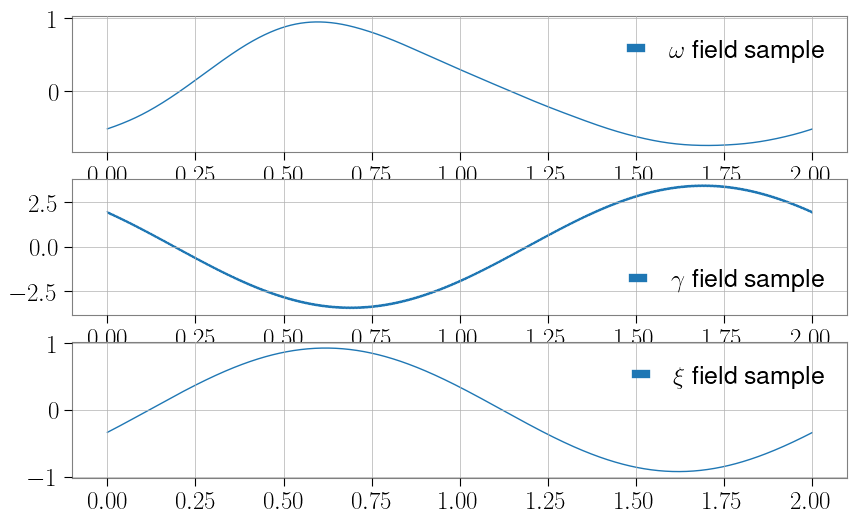

In [10]:
coarse_times = np.linspace(min(gw_times), max(gw_times), 1000)
# coarse_times = gw_times

def create_cfm(prefix):
    cfm_maker = jft.CorrelatedFieldMaker(prefix=prefix)
    cfm_maker.set_amplitude_total_offset(offset_mean=0, offset_std=(1e-16,1e-16))
    cfm_maker.add_fluctuations(shape=len(coarse_times), distances=coarse_times[1]-coarse_times[0], fluctuations=(2,1), loglogavgslope=(-4, 2),
                               flexibility=(1,11), non_parametric_kind="power", harmonic_type="fourier")
    return cfm_maker.finalize()


def draw_realization(operator, sampling_key):
    sampling_key, subkey = jax.random.split(sampling_key)
    sample_domain = jft.random_like(sampling_key, primals=operator.domain)
    sample = operator(sample_domain)
    return sample, sampling_key


def draw_and_plot_field_realizations(omega_field, gamma_field, xi_field, key):
    operators = [omega_field, gamma_field, xi_field]
    sample_list = []
    for operator in operators:
        sample, key = draw_realization(operator, key)
        sample_list.append(sample)

    fig, axs = plt.subplots(3, 1)
    axs[0].plot(coarse_times, sample_list[0], label=r"$\omega$ field sample")
    axs[1].plot(coarse_times, sample_list[1], label=r"$\gamma$ field sample")
    axs[2].plot(coarse_times, sample_list[2], label=r"$\xi$ field sample")

    for ax in axs:
        ax.legend()

    plt.show()
    return sample_list, key


omega_cfm = create_cfm(prefix="omega")
gamma_cfm = create_cfm(prefix="gamma")
xi_cfm = create_cfm(prefix="xi")

print("key: ", key)

operator_samples, key = draw_and_plot_field_realizations(omega_cfm, gamma_cfm, xi_cfm, key)
ivp_omega_interp, ivp_gamma_interp, ivp_xi_interp = [interp1d(x=coarse_times, y=field, kind="linear", fill_value="extrapolate") for field in operator_samples]

In [ ]:
time_points, h, dot_h = runge_kutta_solver(solver_name="RK45",final_time=gw_times.max(), y_init=(0,0), arg_list=[ivp_omega_interp, ivp_gamma_interp, ivp_xi_interp])

In [ ]:
plt.plot(time_points, h, "b-", label="$h(t)$")
# plt.plot(time_points, dot_h, "r.", label="$h(t)$ derivative")
plt.legend()
plt.show()

## Setup Bayesian inference with auto-differentiable diff equ solver as forward model

In [6]:
import diffrax
import jax
jax.config.update("jax_enable_x64", True)
import nifty.nifty.re as jft
from phase_II.nifty_re_playground.useful.helpers import *
key = jax.random.PRNGKey(42)

In [5]:
path1 = "/Users/iason/PycharmProjects/STRAIN/data/data_txt/num_rel_template_strain_values.txt"
path2 = "/Users/iason/PycharmProjects/STRAIN/data/data_txt/num_rel_template_time_values.txt"
gw_waveform = np.loadtxt(path1)*1e21
gw_times = np.loadtxt(path2)
gw_times = gw_times-gw_times[0]

In [8]:
inference = InferenceSchemeRe(t=gw_times, d=gw_waveform, key=key, e_fac=1, r_fac=1)
inference.add_noise_op(noise_var_level=1)

Using DIAGONAL noise operators.


In [ ]:
def create_cfm(downsampled_times, prefix, offset_std, fluct, llslope, flex=None):
    """

    :param downsampled_times:   To speed up the solving of the differential equation, when using an adaptive step size
                                solver, the times may be chosen quite coarse in order to not force very small steps.
    :param prefix:              The model prefix.
    :param offset_std:
    :param fluct:
    :param llslope:
    :return:
    """
    N = len(downsampled_times)
    dt = downsampled_times[1]-downsampled_times[0]
    cfm_maker = jft.CorrelatedFieldMaker(prefix=prefix)
    cfm_maker.set_amplitude_total_offset(offset_mean=0, offset_std=offset_std)
    cfm_maker.add_fluctuations(shape=N, distances=dt, fluctuations=fluct, loglogavgslope=llslope,
                               flexibility=flex, non_parametric_kind="power", harmonic_type="fourier")
    return cfm_maker.finalize(), cfm_maker.power_spectrum

class AutoDiffEquationSolver(jft.Model):
    def __init__(self, omega_cfm, gamma_cfm, xi_cfm):
        self.omega_cfm = omega_cfm
        self.gamma_cfm = gamma_cfm
        self.xi_cfm = xi_cfm
        self.dom = self.omega_cfm.domain | self.gamma_cfm.domain | self.xi_cfm.domain
        super().__init__(domain=self.dom)

    def __call__(self, p):
        pass